In [55]:
%%capture
!pip install lightning

  Obtaining dependency information for lightning from https://files.pythonhosted.org/packages/9e/1b/67201d693a575e8a086831710f33e697fab66166223f792e459ef2b84934/lightning-2.5.1.post0-py3-none-any.whl.metadata
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 819.0/819.0 kB 203.2 kB/s eta 0:00:0000:0100:01

[notice] A new release of pip is available: 23.2.1 -> 25.1.1
[notice] To update, run: pip install --upgrade pip


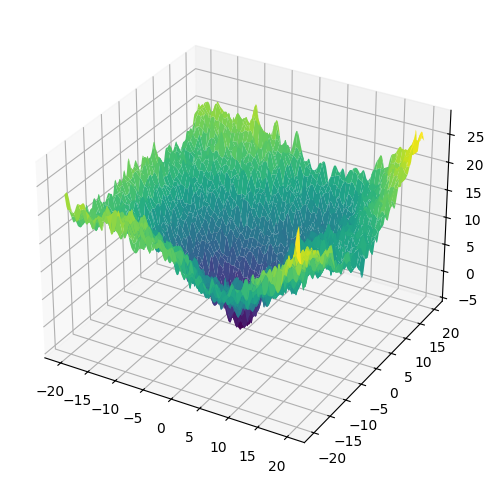

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter
from mpl_toolkits.mplot3d import Axes3D

# パラメータ設定
A = 5        # クレーターの深さ
sigma = 3    # クレーターの広がり
B = 0.8      # 傾斜の強さ
C = 6.0      # ノイズの強さ
D = 4        # うねりの強さ
alpha = 0.2  # うねりの周波数
flatten_scale = 1  # 縦方向スケーリング
noise_smooth = 1.8   # ノイズの平滑度（大きいと低周波）

# 格子状のx, y座標
x = np.linspace(-20, 20, 200)
y = np.linspace(-20, 20, 200)
X, Y = np.meshgrid(x, y)
R = np.sqrt(X**2 + Y**2)

# ノイズ生成 + 平滑化で周波数構造を加える
np.random.seed(0)
raw_noise = np.random.normal(scale=1.0, size=R.shape)
structured_noise = gaussian_filter(raw_noise, sigma=noise_smooth)

# 地形関数（D項追加 & 高さ圧縮）
Z = (
    -A * np.exp(-R**2 / (2 * sigma**2)) + 
    B * R +
    C * structured_noise +  # 空間的構造を持つノイズ
    D * np.sin(alpha * X) * np.cos(alpha * Y)
)
Z *= flatten_scale

# 描画
fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(X, Y, Z, cmap='viridis', edgecolor='none')
ax.set_zlim(Z.min(), Z.max())
plt.show()

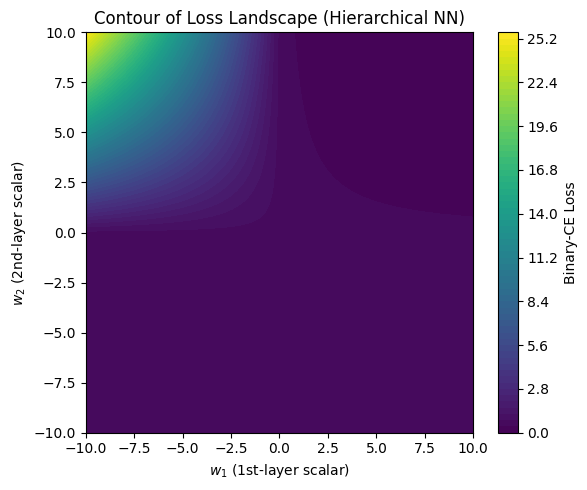

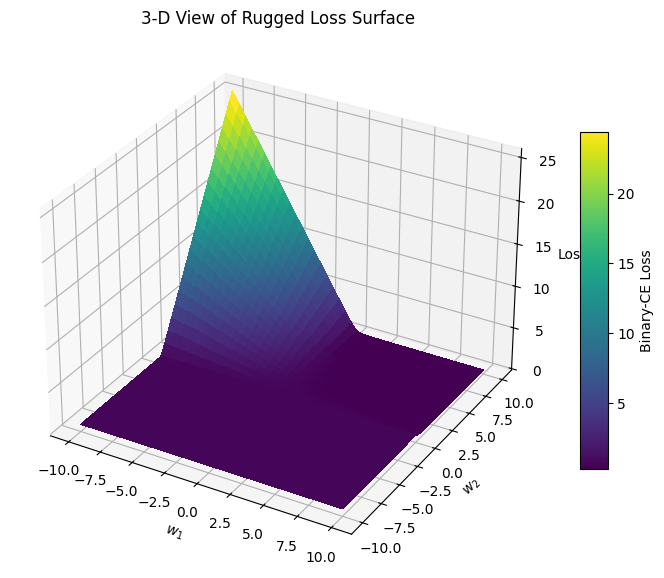

In [2]:
# =========================================
# Rugged Loss-Landscape Demo (hierarchical NN)
# =========================================
# Google Colab / Jupyter Notebook で即実行可
# -----------------------------------------
# Original Color Palette
# -----------------------------------------
color_palette = {
    "white": "#FFFFFF",
    "light_gray": "#D3D3D3",
    "gray": "#808080",
    "black": "#000000",
    "green": "#008000",
    "blue": "#0000FF",
    "light_blue": "#ADD8E6",
    "light_light_blue": "#E0FFFF",
    "yellow": "#FFFF00",
    "orange": "#FFA500",
    "dark_orange": "#FF8C00",
    "purple": "#800080",
}

import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401 (for 3-D proj)

# ----------------------------
# 乱数固定で完全再現性を確保
# ----------------------------
np.random.seed(0)
torch.manual_seed(0)

# ----------------------------
# 1-D ステップ関数分類タスク
# ----------------------------
n = 200
x_np = np.linspace(-1.0, 1.0, n).reshape(-1, 1).astype(np.float32)
y_np = (x_np > 0).astype(np.float32)  # 0 or 1
x = torch.from_numpy(x_np)
y = torch.from_numpy(y_np)

# ----------------------------
# 階層 3 層 ReLU ネットを定義
# （重み・バイアスの大半は固定）
# ----------------------------
# 可変にする 2 スカラ重み
def loss_for_weights(w1_scalar, w2_scalar):
    # 固定パラメータ
    b1, b2 = 0.0, 0.0
    w3, b3 = 1.0, 0.0
    # ---- forward ----
    h1 = F.relu(w1_scalar * x + b1)              # 第1層
    h2 = F.relu(w2_scalar * h1 + b2)             # 第2層（階層的）
    logits = w3 * h2 + b3                        # 出力層
    loss = F.binary_cross_entropy_with_logits(logits, y)
    return loss.item()

# ----------------------------
# グリッド計算
# ----------------------------
grid_size = 120          # 120×120 ≈ 14k 評価
w_range = np.linspace(-10, 10, grid_size)
W1, W2 = np.meshgrid(w_range, w_range)
Z = np.zeros_like(W1)

for i in range(grid_size):
    for j in range(grid_size):
        Z[j, i] = loss_for_weights(W1[j, i], W2[j, i])  # 行列表示に合わせ転置

# ----------------------------
# 2-D 等高線図（ガタガタ感を先に俯瞰）
# ----------------------------
plt.figure(figsize=(6, 5))
cont = plt.contourf(
    W1, W2, Z,
    levels=80,
    cmap="viridis",
    antialiased=False
)
plt.colorbar(cont, label="Binary-CE Loss")
plt.xlabel("$w_1$ (1st-layer scalar)")
plt.ylabel("$w_2$ (2nd-layer scalar)")
plt.title("Contour of Loss Landscape (Hierarchical NN)")
plt.tight_layout()
plt.show()                 # ------------> 図 1

# ----------------------------
# 3-D サーフェス（凸凹を立体で確認）
# ----------------------------
fig = plt.figure(figsize=(7, 6))
ax = fig.add_subplot(111, projection='3d')
surf = ax.plot_surface(
    W1, W2, Z,
    cmap="viridis",
    linewidth=0,
    antialiased=False
)
ax.set_xlabel("$w_1$")
ax.set_ylabel("$w_2$")
ax.set_zlabel("Loss")
ax.set_title("3-D View of Rugged Loss Surface")
fig.colorbar(surf, shrink=0.6, aspect=12, label="Binary-CE Loss")
plt.tight_layout()
plt.show()                 # ------------> 図 2

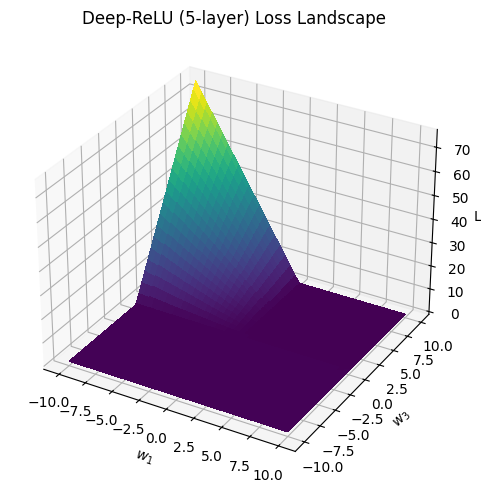

In [5]:
# -----------------------------------------
# Original Color Palette
# -----------------------------------------
import numpy as np, torch, torch.nn.functional as F, matplotlib.pyplot as plt
np.random.seed(0); torch.manual_seed(0)

# 1-D ステップ分類データ
x = torch.linspace(-1., 1., 200).unsqueeze(1)
y = (x > 0).float()

# 5 階層 ReLU（可変 w1, w3）
def loss_for_weights(w1, w3):
    h1 = F.relu(w1 * x)          # 層1
    h2 = F.relu( 2.0 * h1)       # 固定
    h3 = F.relu(w3 * h2)         # 層3
    h4 = F.relu( 1.5 * h3)       # 固定
    logits = 1.0 * h4            # 出力
    return F.binary_cross_entropy_with_logits(logits, y).item()

# グリッド描画
w = np.linspace(-10, 10, 120); W1, W3 = np.meshgrid(w, w); Z = np.zeros_like(W1)
for i in range(120):
    for j in range(120):
        Z[j, i] = loss_for_weights(W1[j, i], W3[j, i])

fig = plt.figure(figsize=(6,5)); ax = fig.add_subplot(111, projection="3d")
surf = ax.plot_surface(W1, W3, Z, cmap="viridis", linewidth=0, antialiased=False)
ax.set_xlabel("$w_1$"); ax.set_ylabel("$w_3$"); ax.set_zlabel("Loss")
ax.set_title("Deep-ReLU (5-layer) Loss Landscape"); plt.tight_layout(); plt.show()

hidden_dim = 1


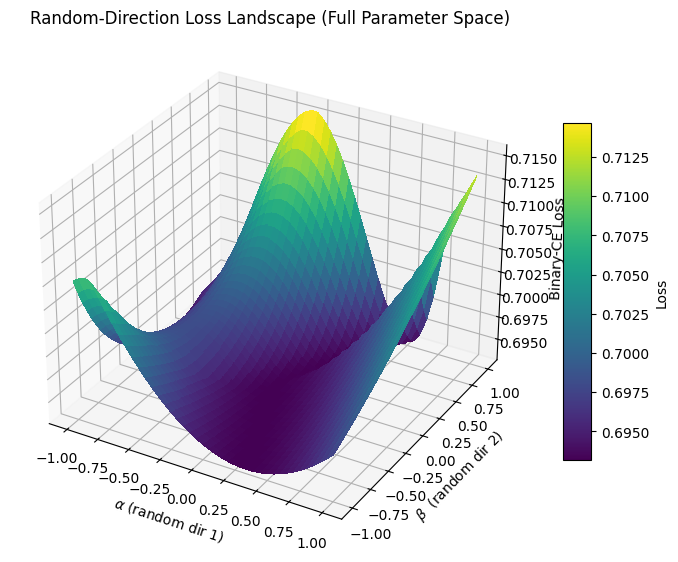

hidden_dim = 2


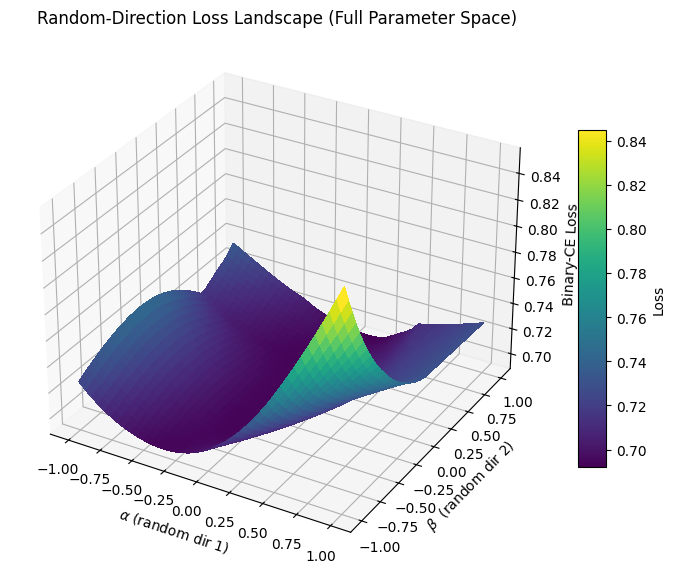

hidden_dim = 3


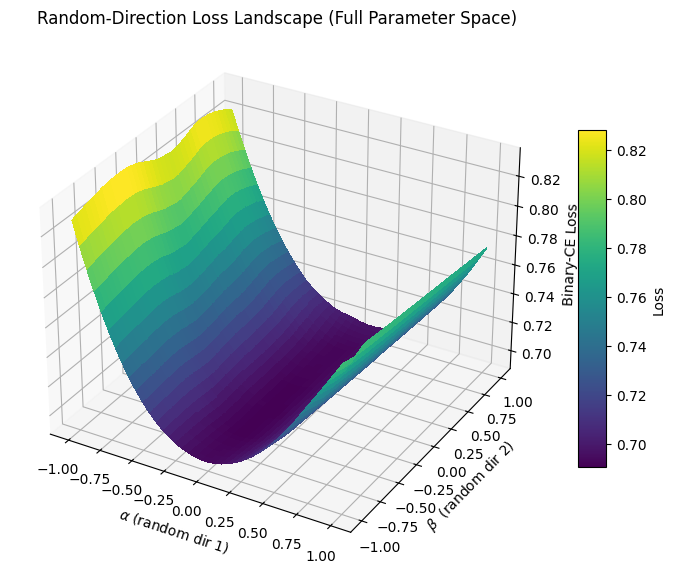

hidden_dim = 4


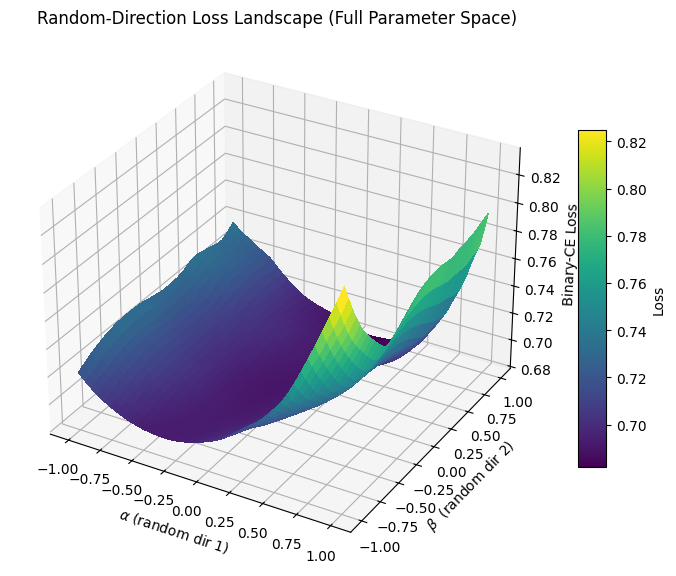

hidden_dim = 5


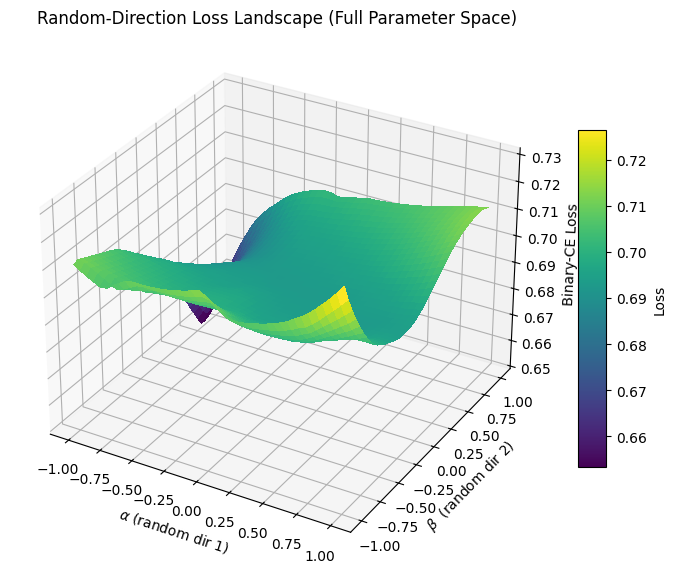

hidden_dim = 6


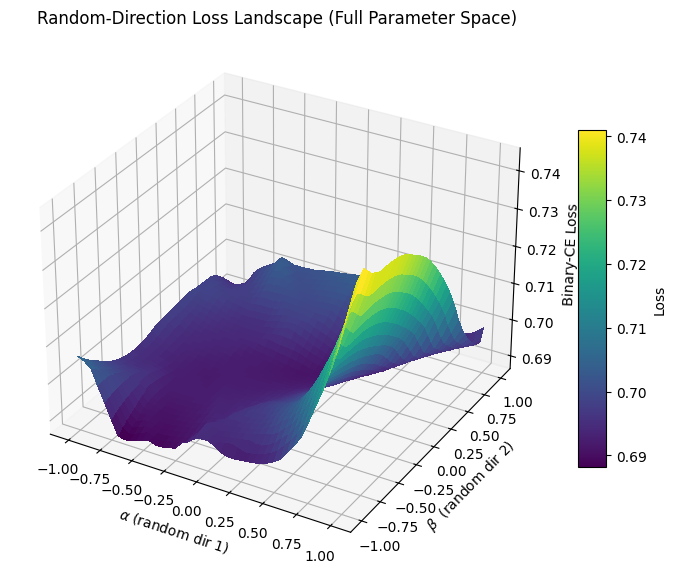

hidden_dim = 7


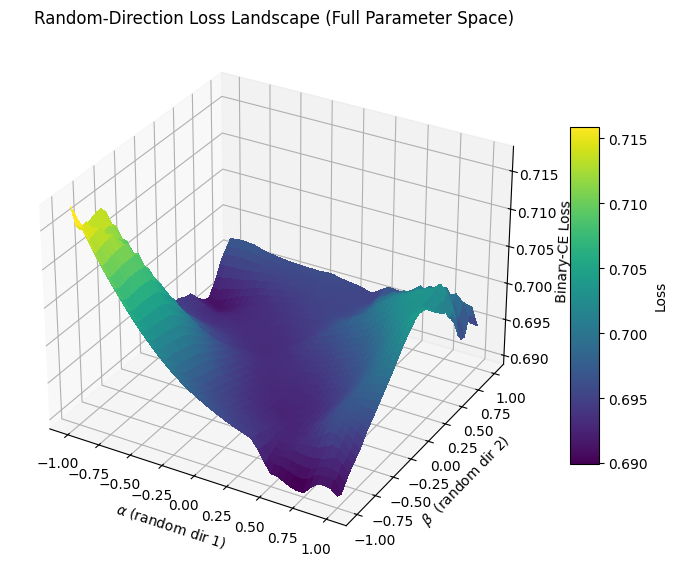

hidden_dim = 8


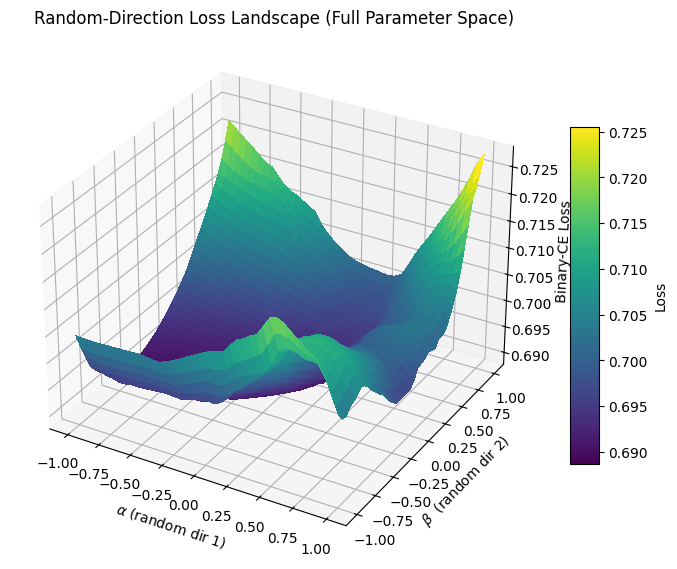

hidden_dim = 9


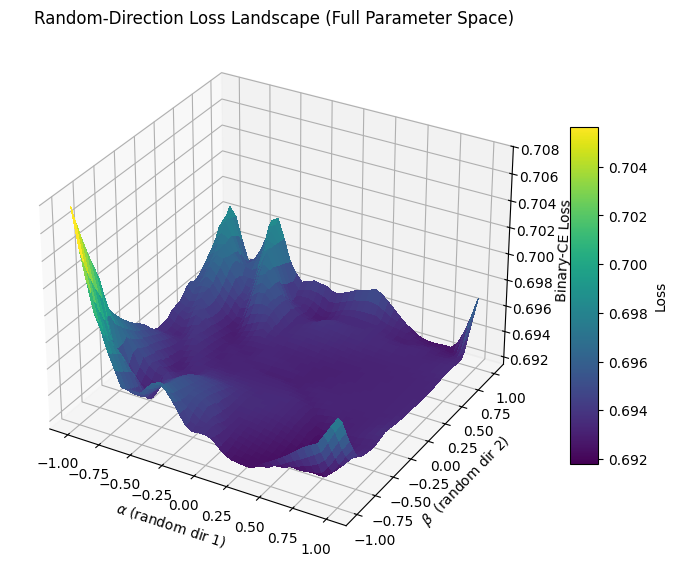

hidden_dim = 10


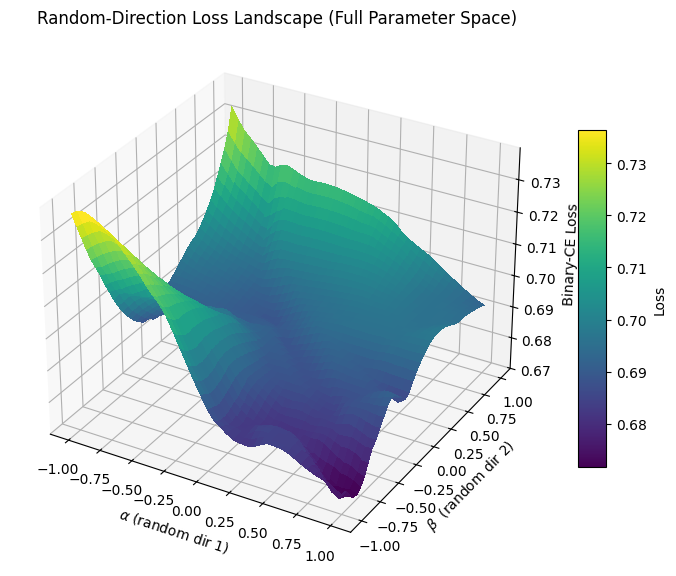

hidden_dim = 11


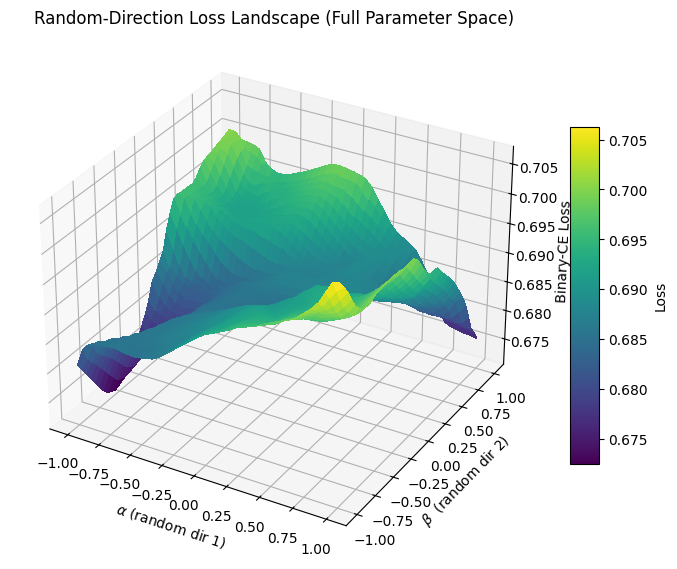

hidden_dim = 12


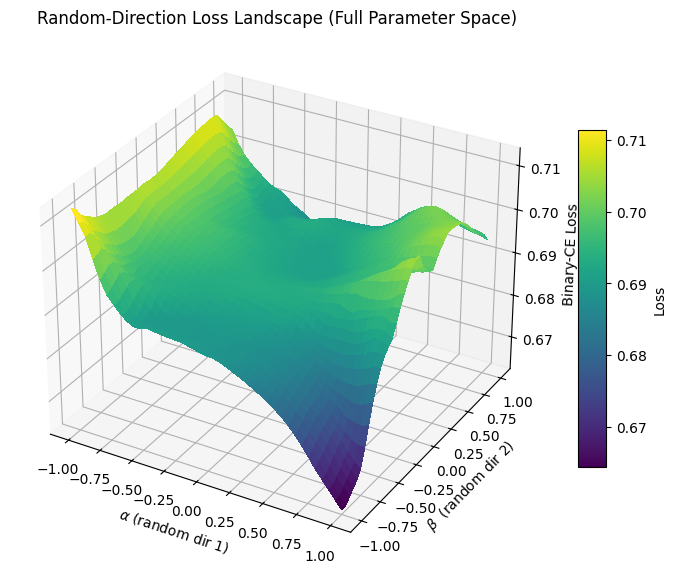

hidden_dim = 13


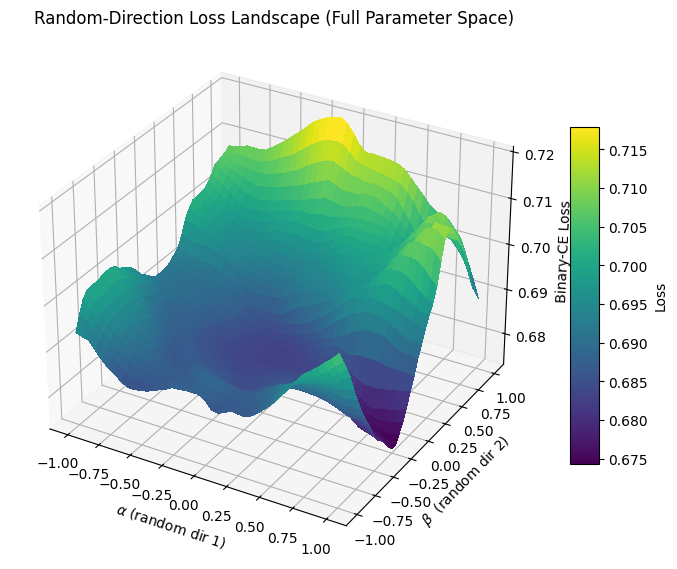

hidden_dim = 14


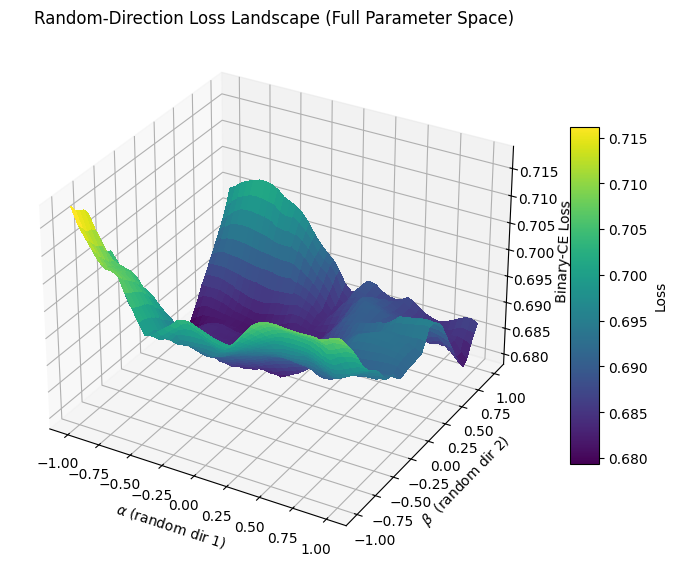

hidden_dim = 15


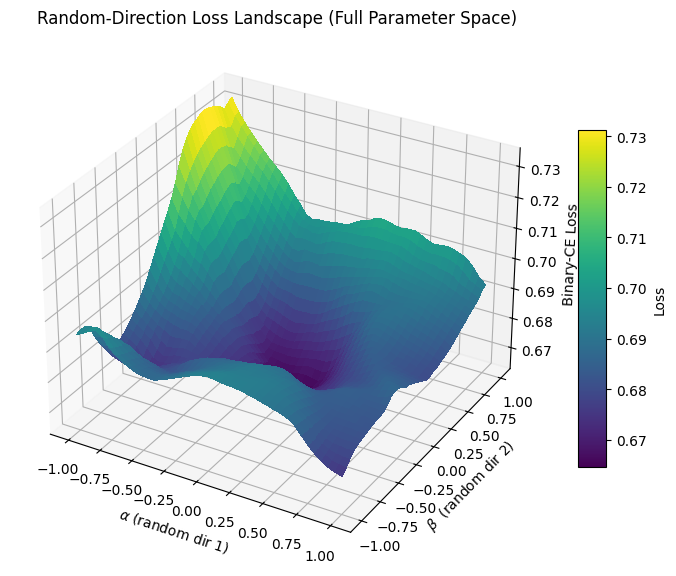

hidden_dim = 16


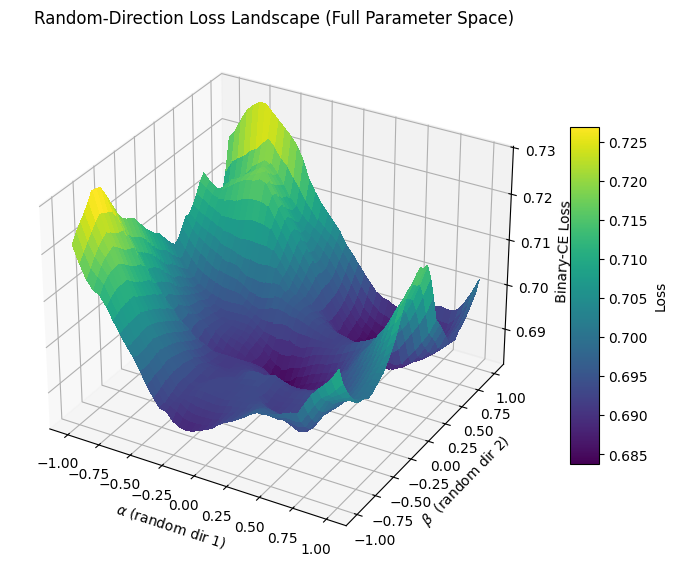

hidden_dim = 17


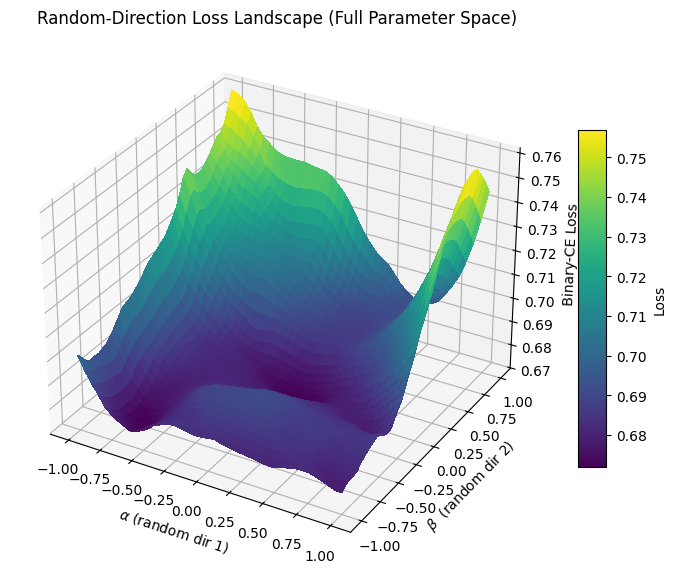

hidden_dim = 18


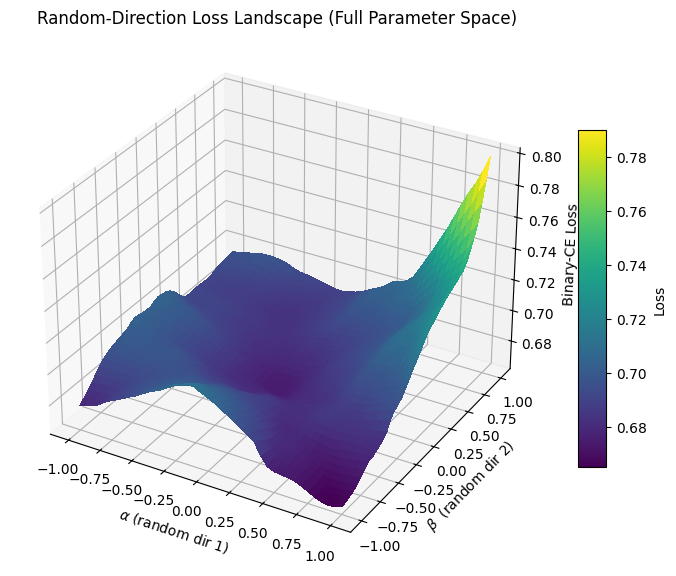

hidden_dim = 19


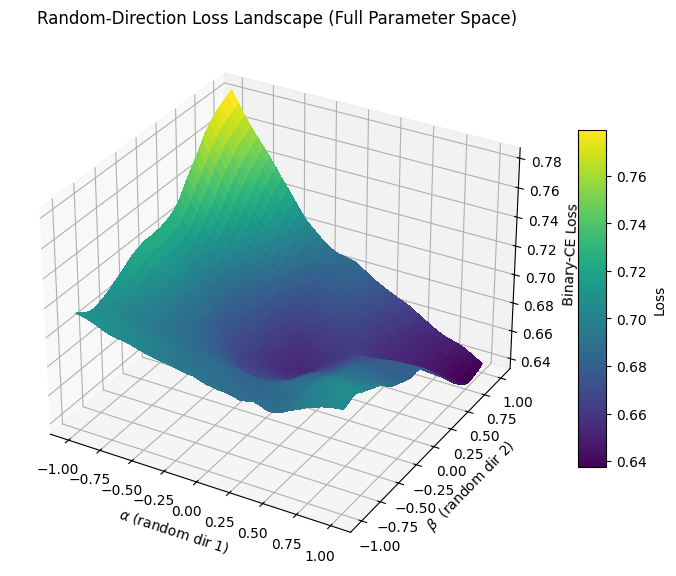

hidden_dim = 20


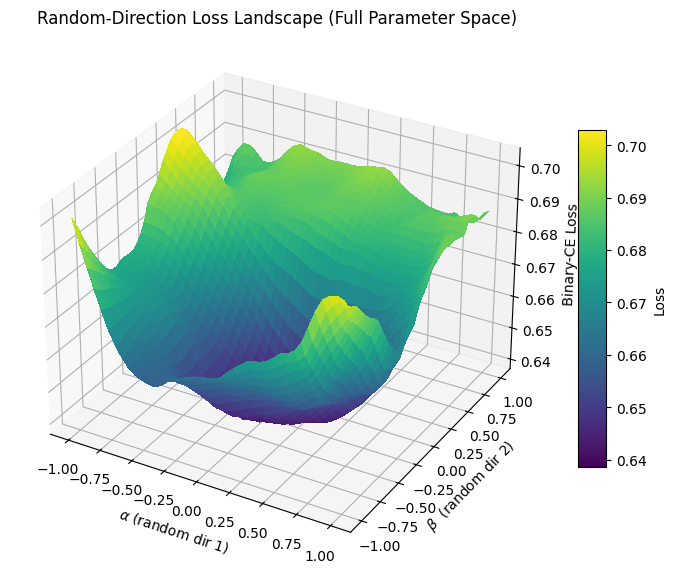

hidden_dim = 21


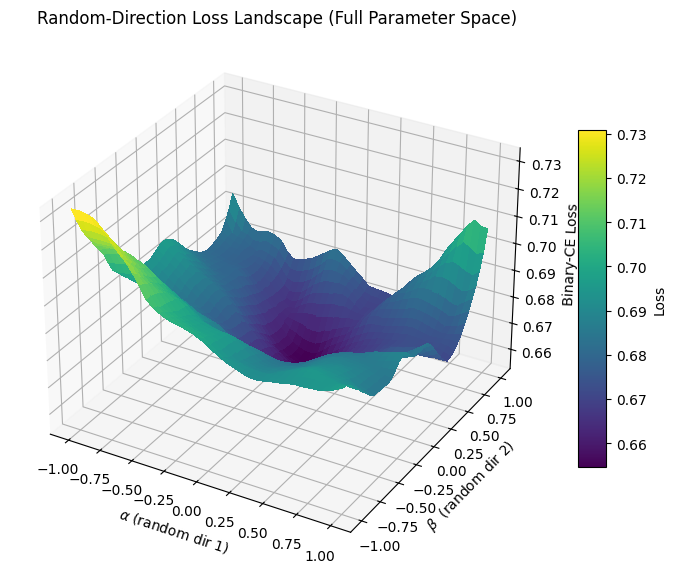

hidden_dim = 22


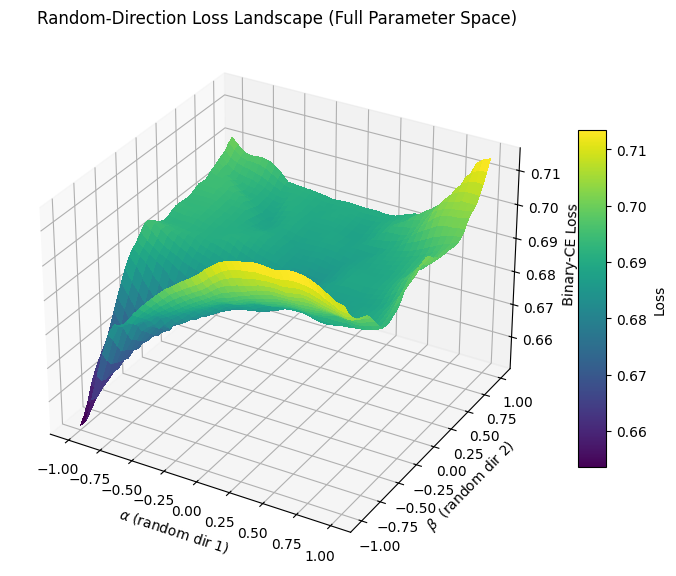

hidden_dim = 23


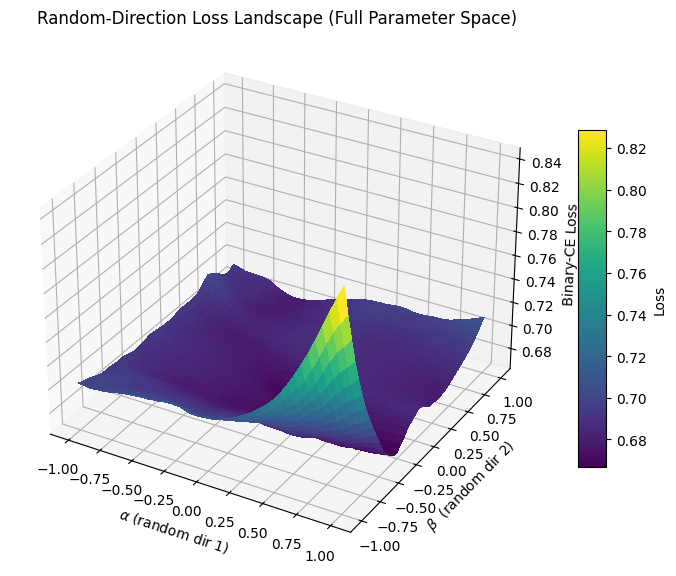

hidden_dim = 24


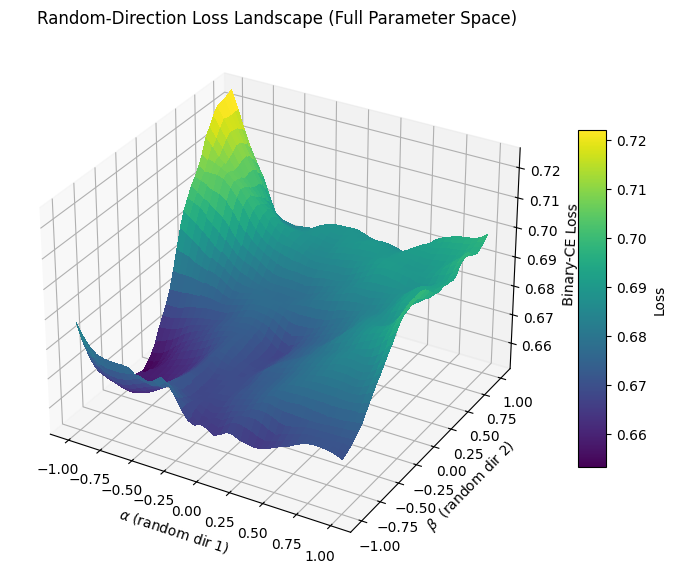

hidden_dim = 25


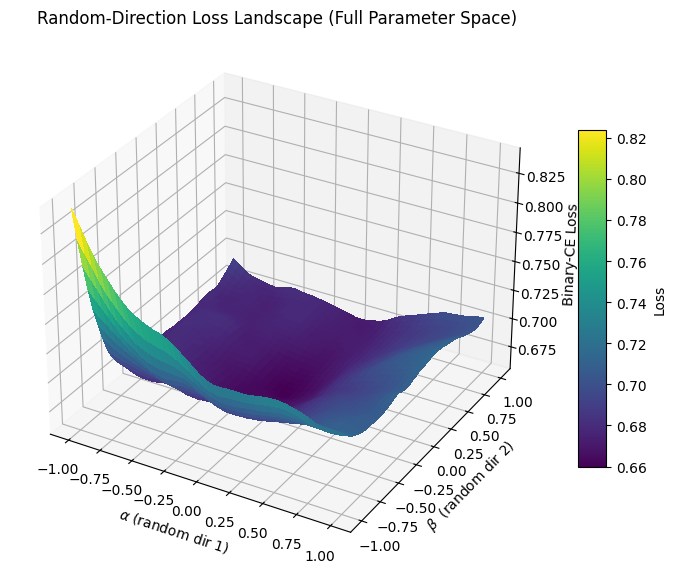

hidden_dim = 26


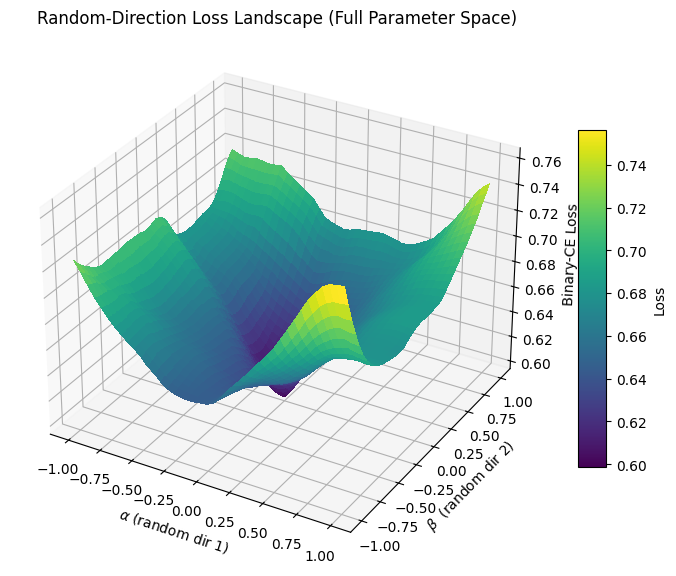

hidden_dim = 27


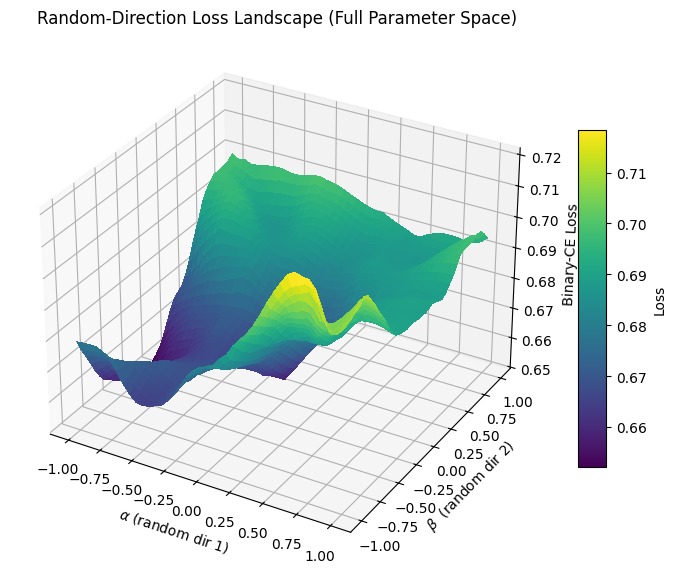

hidden_dim = 28


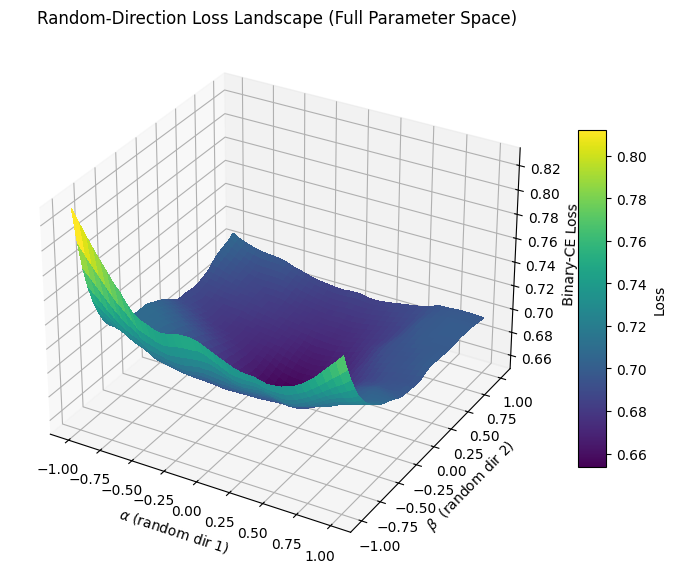

hidden_dim = 29


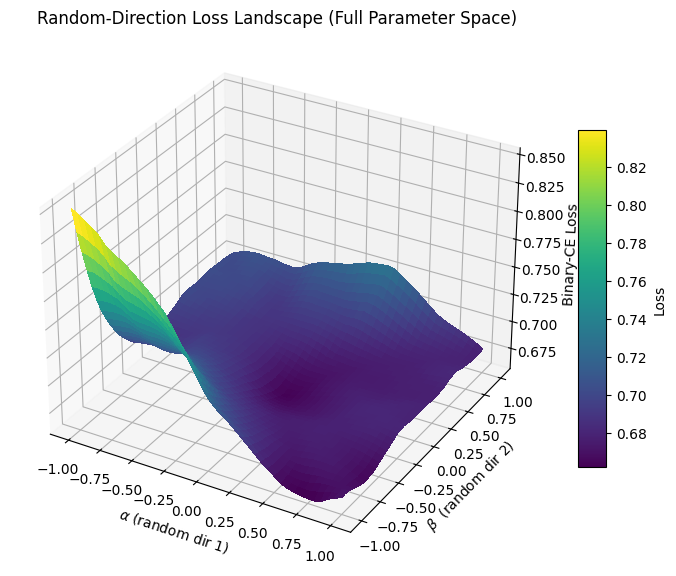

hidden_dim = 30


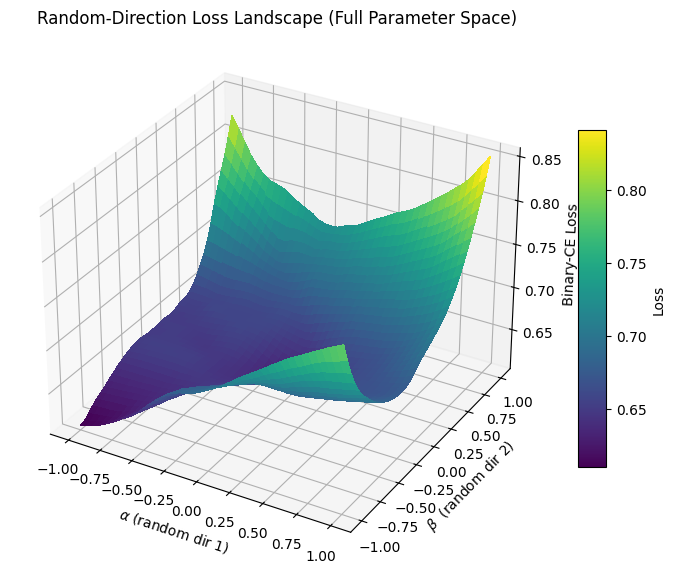

hidden_dim = 31


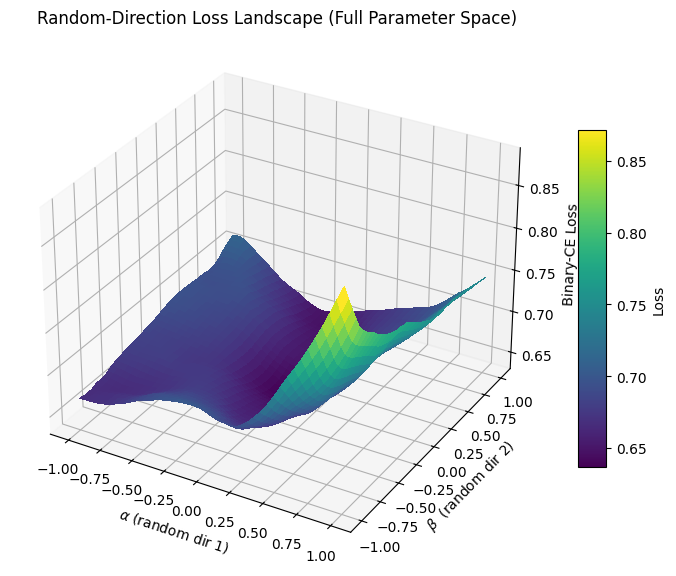

In [52]:
# =========================================
# Random-Direction Loss Landscape (Full Params)
# =========================================
# Google Colab / Jupyter Notebook で即実行可
# -----------------------------------------
# Original Color Palette
# -----------------------------------------
color_palette = {
    "white": "#FFFFFF",
    "light_gray": "#D3D3D3",
    "gray": "#808080",
    "black": "#000000",
    "green": "#008000",
    "blue": "#0000FF",
    "light_blue": "#ADD8E6",
    "light_light_blue": "#E0FFFF",
    "yellow": "#FFFF00",
    "orange": "#FFA500",
    "dark_orange": "#FF8C00",
    "purple": "#800080",
}

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
from torch.nn.utils import parameters_to_vector, vector_to_parameters

# ----------------------------
# 再現性
# ----------------------------
np.random.seed(0)
torch.manual_seed(0)

# ----------------------------
# XOR データセット (float32)
# ----------------------------
x_np = np.array([[0,0],[0,1],[1,0],[1,1]], dtype=np.float32)
y_np = np.array([[0],[1],[1],[0]], dtype=np.float32)
x = torch.from_numpy(x_np)
y = torch.from_numpy(y_np)

# ----------------------------
# 3 層 MLP で学習 (ReLU 8-8-8)
# ----------------------------
class SmallMLP(nn.Module):
    def __init__(self, hidden_dim=8):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 1)
        )
    def forward(self, z):
        return self.net(z)

for hidden_dim in range(1, 32):
    # ----------------------------
    # 再現性
    # ----------------------------
    np.random.seed(0)
    torch.manual_seed(0)

    print(f"hidden_dim = {hidden_dim}")
    model = SmallMLP(hidden_dim=hidden_dim)
    optim = torch.optim.SGD(model.parameters(), lr=0.1)
    # --- quick train (100 epochs) ---
    for _ in range(100):
        logits = model(x)
        loss = F.binary_cross_entropy_with_logits(logits, y)
        optim.zero_grad()
        loss.backward()
        optim.step()
    base_loss = loss.item()  # baseline for reference

    # ----------------------------
    # ベースパラメータベクトル & ランダム直交方向
    # ----------------------------
    base_vec = parameters_to_vector(model.parameters()).detach()

    def random_unit_direction(dim):
        v = torch.randn(dim)
        v /= v.norm() + 1e-12
        return v

    dim = base_vec.numel()
    d1 = random_unit_direction(dim)
    d2 = random_unit_direction(dim)
    # Gram-Schmidt で直交化
    d2 -= (d2 @ d1) * d1
    d2 /= d2.norm() + 1e-12

    # Li et al. の “filter normalization” に倣い
    # 各方向ベクトルを base_vec の  L2 ノルムでスケーリング
    scale = base_vec.norm()
    d1 *= scale
    d2 *= scale

    # ----------------------------
    # 2-D グリッド上で損失評価
    # ----------------------------
    grid_size = 41          # 41×41 ≈ 1.6k 点
    range_scale = 1.0
    alpha_range = np.linspace(-range_scale, range_scale, grid_size, dtype=np.float32)
    beta_range  = np.linspace(-range_scale, range_scale, grid_size, dtype=np.float32)
    ALPHA, BETA = np.meshgrid(alpha_range, beta_range)
    Z = np.zeros_like(ALPHA)

    for i in range(grid_size):
        for j in range(grid_size):
            a = float(ALPHA[j, i])
            b = float(BETA[j, i])
            # パラメータを base + a*d1 + b*d2 に置き換える
            vec = base_vec + a * d1 + b * d2
            vector_to_parameters(vec, model.parameters())
            logits = model(x)
            Z[j, i] = F.binary_cross_entropy_with_logits(logits, y).item()

    # 終了後にモデルを元に戻す
    vector_to_parameters(base_vec, model.parameters())

    # ----------------------------
    # 3-D サーフェスプロット
    # ----------------------------
    fig = plt.figure(figsize=(7, 6))
    ax = fig.add_subplot(111, projection='3d')
    surf = ax.plot_surface(
        ALPHA, BETA, Z,
        cmap="viridis",
        linewidth=0,
        antialiased=False
    )
    ax.set_xlabel(r"$\alpha$ (random dir 1)")
    ax.set_ylabel(r"$\beta$  (random dir 2)")
    ax.set_zlabel("Binary-CE Loss")
    ax.set_title("Random-Direction Loss Landscape (Full Parameter Space)")
    fig.colorbar(surf, shrink=0.6, aspect=12, label="Loss")
    plt.tight_layout()
    plt.show()

In [57]:
# =========================================
# Loss Surface & SGD Trajectory (Lightning, fixed)
# =========================================
# ⚠️ 事前に  !pip install lightning  を実行しておいてください
# -----------------------------------------
import numpy as np
import torch
import torch.nn as nn
import lightning as L
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
from torch.utils.data import DataLoader, TensorDataset
from torch.nn.utils import parameters_to_vector, vector_to_parameters

# 再現性
np.random.seed(0); torch.manual_seed(0)

# -----------------------------------------
# XOR データ：最初に Tensor 化して固定で使う
# -----------------------------------------
X = torch.tensor([[0,0],[0,1],[1,0],[1,1]], dtype=torch.float32)
Y = torch.tensor([[0],[1],[1],[0]], dtype=torch.float32)
loader = DataLoader(TensorDataset(X, Y), batch_size=4, shuffle=False)

# -----------------------------------------
# LightningModule
# -----------------------------------------
class XORNet(L.LightningModule):
    def __init__(self, hidden_dim, lr=0.05):
        super().__init__()
        hd = hidden_dim
        self.model = nn.Sequential(
            nn.Linear(2, hd), nn.ReLU(),
            nn.Linear(hd, hd), nn.ReLU(),
            nn.Linear(hd, hd), nn.ReLU(),
            nn.Linear(hd, 1)
        )
        self.crit = nn.BCEWithLogitsLoss()
        self.lr = lr

    def forward(self, z):           return self.model(z)
    def training_step(self, b, _):  return self.crit(self(b[0]), b[1])
    def configure_optimizers(self): return torch.optim.SGD(self.parameters(), lr=self.lr)

# -----------------------------------------
# ユーティリティ
# -----------------------------------------
def rand_dirs(dim, base_norm):
    d1 = torch.randn(dim); d1 /= d1.norm()
    d2 = torch.randn(dim) - (torch.dot(d1, torch.randn(dim))) * d1
    d2 /= d2.norm()
    return d1*base_norm, d2*base_norm

@torch.no_grad()
def surface(model, cvec, d1, d2, gs=41, span=1.0):
    a = np.linspace(-span, span, gs, dtype=np.float32)
    A, B = np.meshgrid(a, a); Z = np.zeros_like(A)
    for i in range(gs):
        for j in range(gs):
            vec = cvec + A[j,i]*d1 + B[j,i]*d2
            vector_to_parameters(vec, model.parameters())
            Z[j,i] = model.crit(model(X), Y).item()
    vector_to_parameters(cvec, model.parameters())
    return A, B, Z

# -----------------------------------------
# メイン
# -----------------------------------------
hidden_dims  = [2, 4, 8, 16]
steps, rec = 300, 10
span = 1.0

for hd in hidden_dims:
    print(f"\n=== hidden_dim = {hd} ===")
    net = XORNet(hd)
    w0  = parameters_to_vector(net.parameters()).detach()
    d1, d2 = rand_dirs(w0.numel(), w0.norm())
    d1s, d2s = (d1@d1).item(), (d2@d2).item()

    A,B,Z = surface(net, w0, d1, d2, span=span)

    traj_a, traj_b, traj_l = [0],[0],[net.crit(net(X),Y).item()]
    class Rec(L.Callback):
        def on_train_batch_end(self,tr,pl,o,b,idx):
            if tr.global_step%rec==0 or tr.global_step==steps:
                w = parameters_to_vector(pl.parameters()).detach()
                d = w-w0; traj_a.append((d@d1).item()/d1s); traj_b.append((d@d2).item()/d2s)
                traj_l.append(o.item())

    L.Trainer(max_epochs=steps, logger=False, enable_progress_bar=False,
              callbacks=[Rec()], deterministic=True).fit(net, loader)

    # ---- Plot ----
    fig=plt.figure(figsize=(7,6)); ax=fig.add_subplot(111, projection='3d')
    ax.plot_surface(A,B,Z,cmap="viridis",linewidth=0,antialiased=False)
    ax.plot(traj_a,traj_b,traj_l,color='r',lw=3)
    ax.scatter(traj_a[0],traj_b[0],traj_l[0],c='b',s=60,label='start')
    ax.scatter(traj_a[-1],traj_b[-1],traj_l[-1],c='k',s=60,label='final')
    ax.set_xlabel(r"$\alpha$"); ax.set_ylabel(r"$\beta$"); ax.set_zlabel("Loss")
    ax.set_title(f"hidden_dim={hd}"); ax.legend(); plt.tight_layout(); plt.show()


=== hidden_dim = 2 ===


Using default `ModelCheckpoint`. Consider installing `litmodels` package to enable `LitModelCheckpoint` for automatic upload to the Lightning model registry.
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/Users/teshima/lecture-supplement-material/Introduction-to-AI/.venv/lib/python3.11/site-packages/lightning/pytorch/callbacks/model_checkpoint.py:654: Checkpoint directory /Users/teshima/lecture-supplement-material/Introduction-to-AI/checkpoints exists and is not empty.

  | Name  | Type              | Params | Mode 
----------------------------------------------------
0 | model | Sequential        | 21     | train
1 | crit  | BCEWithLogitsLoss | 0      | train
----------------------------------------------------
21        Trainable params
0         Non-trainable params
21        Total params
0.000     Total estimated model params size (MB)
9         Modules in train mode
0         Modules in eval mode
/Users/teshima/lectu

AttributeError: 'dict' object has no attribute 'item'